In [20]:
# import the pandas library
import pandas as pd

In [21]:
# Change html
from IPython.core.display import HTML
# Changing how the table looks to make it more presentable
with open('custom.css') as f:
    css = f.read()
HTML(f'<style>{css}</style>')

In [22]:
# Get the tiles dataframe
df = pd.read_csv('data/titles.zip')

In [23]:
# Taking a quick look
df.head()

,title,year,rating,votes
0,Spanish Fiesta,2019,6.9,29
1,La tierra de los toros,2000,5.4,14
2,Dama de noche,1993,6.0,25
3,Frivolinas,2014,5.6,19
4,Mya ga naing,1996,7.5,21


#### How many movies are there in `titles.csv` ?

1. `len(df)`
2. `.shape`

In [24]:
# The number of movies 
print(len(df))
print(df.shape)

213665
(213665, 4)


#### Columns ?

In [25]:
df.columns

Index(['title', 'year', 'rating', 'votes'], dtype='object')

In [26]:
subselection = ['title','year']
df[subselection]

,title,year
0,Spanish Fiesta,2019
1,La tierra de los toros,2000
2,Dama de noche,1993
3,Frivolinas,2014
4,Mya ga naing,1996
...,...,...
213660,Safeguard,2020
213661,Il talento del calabrone,2020
213662,Coven,2020
213663,The Secret of China,2019


In [27]:
# Pass in a string instead of a list
df['title']

0                   Spanish Fiesta
1           La tierra de los toros
2                    Dama de noche
3                       Frivolinas
4                     Mya ga naing
                    ...           
213660                   Safeguard
213661    Il talento del calabrone
213662                       Coven
213663         The Secret of China
213664         Kuambil Lagi Hatiku
Name: title, Length: 213665, dtype: object

### What is `pd.Series`

- Labeled array
- Like a dictionary

In [28]:
# Another column
df['year']

0         2019
1         2000
2         1993
3         2014
4         1996
          ... 
213660    2020
213661    2020
213662    2020
213663    2019
213664    2019
Name: year, Length: 213665, dtype: int64

<AxesSubplot:>

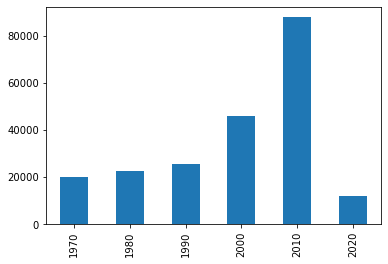

In [29]:
decades = df['year']//10*10
decade_counts = decades.value_counts()
sorted_dc = decade_counts.sort_index()
sorted_dc.plot(kind='bar')

#### Chaining operations
- Chain multiple outputs
- Chaining from left to right
- Keep in mind the parenthesis 

<AxesSubplot:>

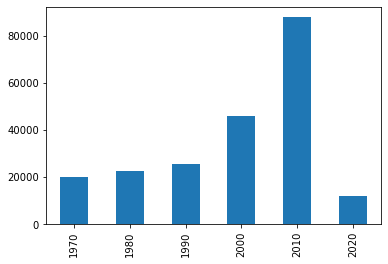

In [30]:
# Same operation but with chaining
(df.year//10*10).value_counts().sort_index().plot(kind='bar')

### Using `pd.series` to get a subselection of a dataframe

In [31]:
# Another way to access to access a dataframe
s1 = df.year//10 * 10 > 1990

In [32]:
# Create a boolean series
s1

0          True
1          True
2         False
3          True
4         False
          ...  
213660     True
213661     True
213662     True
213663     True
213664     True
Name: year, Length: 213665, dtype: bool

In [33]:
# New dataframe using a boolean series
df[s1]

,title,year,rating,votes
0,Spanish Fiesta,2019,6.9,29
1,La tierra de los toros,2000,5.4,14
3,Frivolinas,2014,5.6,19
6,Kate & Leopold,2001,6.4,81684
7,Muhomatsu no issho,2008,7.3,108
...,...,...,...,...
213660,Safeguard,2020,3.5,225
213661,Il talento del calabrone,2020,5.8,1197
213662,Coven,2020,6.4,4014
213663,The Secret of China,2019,3.8,14


#### Working with string data

In [34]:
# Using the .str methods
s2 = df.title.str.contains('Love')

In [35]:
# 
s2

0         False
1         False
2         False
3         False
4         False
          ...  
213660    False
213661    False
213662    False
213663    False
213664    False
Name: title, Length: 213665, dtype: bool

In [36]:
df[s2]

,title,year,rating,votes
53,Love Toy,1971,4.9,131
64,"Love, Emilia",1970,6.9,60
137,Love Is a Splendid Illusion,1970,4.9,42
391,Brotherly Love,1970,5.7,348
473,First Love,1970,6.8,348
...,...,...,...,...
213365,Same But Different: A True New Zealand Love Story,2019,6.8,60
213420,Falling Inn Love,2019,5.6,18025
213423,The Love Europe Project,2019,7.3,26
213533,Season of Love,2019,7.4,485


In [37]:
df[s1 & s2]

,title,year,rating,votes
29080,Karobaar: The Business of Love,2000,4.5,258
29976,In the Mood for Love,2000,8.1,137655
30462,Love 101,2000,4.7,149
34036,Love... at Your Disposal,2000,6.2,9
35227,"Life, Love & Celluloid",2005,5.0,63
...,...,...,...,...
213365,Same But Different: A True New Zealand Love Story,2019,6.8,60
213420,Falling Inn Love,2019,5.6,18025
213423,The Love Europe Project,2019,7.3,26
213533,Season of Love,2019,7.4,485


In [38]:
# Looking for unique things
df[df.title.str.contains('Pavlos')]

,title,year,rating,votes
3587,Pavlos Melas,1973,6.6,73
162285,Pavlos. No Ordinary King,2014,6.8,7
